## INSURANCE COST ANALYSIS:

objective:
- Load the data as a pandas dataframe
- Clean the data, taking care of the blank entries
- Run exploratory data analysis (EDA) and identify the attributes that most affect the charges
- Develop single variable and multi variable Linear Regression models for predicting the charges
- Develop a training Pipeline
- Use Ridge regression to refine the performance of Linear regression models.

In [ ]:
#importing required libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split


#### IMPORTING DATASET

In [17]:
#downloading dataset

filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'
df = pd.read_csv(filepath, header=None)

In [18]:
df.head(10)  

#col 4 has visible ? values

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,?,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


In [19]:
#adding column names: (given)
header=["age", "gender", "bmi", "no_of_children", "smoker", "region", "charges"]
df.columns= header
df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [20]:
#for column in df.columns:
    #print(df[column].value_counts(dropna=False)) #smoker column has ? values, replace by nan

In [21]:
df.replace('?', np.nan, inplace=True)
df.head(10)

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,NaN,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


#### DATA WRANGLING

In [22]:
print(df.shape)
print(df.info())

#age and smoker have some nulls

(2772, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB
None


In [23]:
#replacing nulls in age with mean and in smoker with frequency/mode:

mean_age= df['age'].astype(float).mean()
df['age'] = df['age'].fillna(mean_age)

mode_smoker= df['smoker'].value_counts().idxmax()
df.fillna({'smoker': mode_smoker}, inplace=True)


print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB
None


In [27]:
#rounding off charges

df['charges']= np.round(df[['charges']], 2)
df.head()


,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92
1,18,2,33.770,1,0,4,1725.55
2,28,2,33.000,3,0,4,4449.46
3,33,2,22.705,0,0,1,21984.47
4,32,2,28.880,0,0,1,3866.86


#### EXPLORATORY DATA ANALYSIS (EDA):

<Axes: xlabel='bmi', ylabel='charges'>

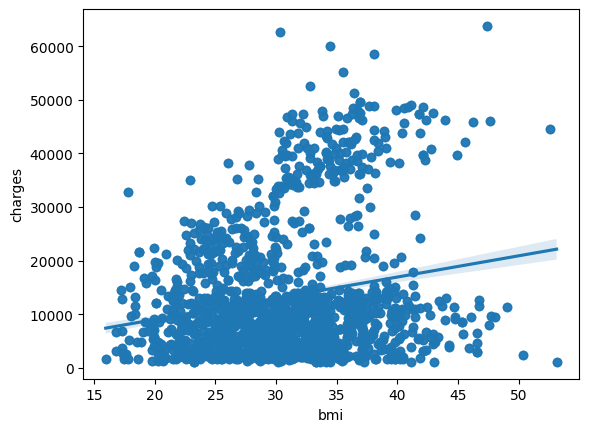

In [31]:
sns.regplot(x='bmi', y='charges', data=df)

- bmi has an impact since there is positive slope but not very strong since points are scattered diversly. 

<Axes: xlabel='smoker', ylabel='charges'>

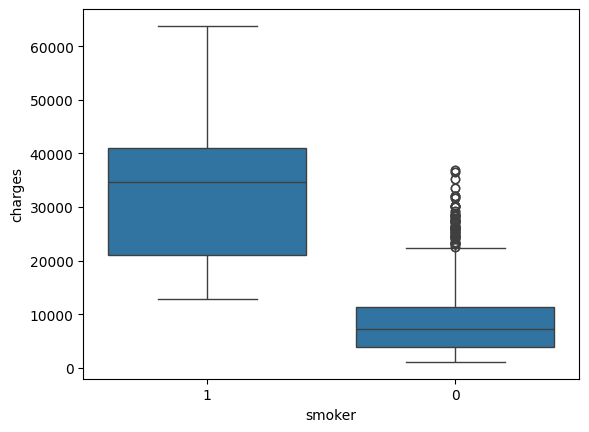

In [34]:
sns.boxplot(x='smoker', y='charges', data=df)

- smokers consistently pay higher charges
- non-smokers have outliers 
- highest non-smoker charges are around 20-22k whereas smoker charges are around 40k highest
- so smoking could be major factor for charges


In [33]:
df.corr()

,age,gender,bmi,no_of_children,smoker,region,charges
age,1.000000,-0.026041,0.113045,0.037585,-0.023285,-0.007175,0.298622
gender,-0.026041,1.000000,0.042924,0.016020,0.082326,0.022213,0.062837
bmi,0.113045,0.042924,1.000000,-0.001492,0.011489,0.271119,0.199846
no_of_children,0.037585,0.016020,-0.001492,1.000000,0.006362,-0.025717,0.066442
smoker,-0.023285,0.082326,0.011489,0.006362,1.000000,0.054077,0.788783
region,-0.007175,0.022213,0.271119,-0.025717,0.054077,1.000000,0.054058
charges,0.298622,0.062837,0.199846,0.066442,0.788783,0.054058,1.000000


- as seen previously, corr between smokers and charges is 0.78 (strongest corr with charges)
- age has some degree of positive relationship and bmi has weak positive correlation
- rest have close to 0 corr so not much significance


In [37]:
df['charges'].skew()

np.float64(1.5113150341708463)

- charges have positive right skew hence small concentration of people pay very high charges


#

#### Model Development

single variable linear regression model:

In [ ]:
lr= LinearRegression()
X= df[['smoker']]
Y=df['charges']
lr.fit(X,Y)
print(lr.score(X,Y)) 

0.6221791733924185


r-square (coeff of determination): 0.62

multi-variable linear regression model:

In [40]:
x= df[['age','gender', 'bmi', 'no_of_children', 'smoker', 'region']]
y=df['charges']
lr.fit(x,y)
print(lr.score(x,y))

0.7504063772187107


r-square (coeff of determination): 0.75

#

training pipeline using StandardScaler(), PolynomialFeatures() and LinearRegression() using x=all other columns to predict y=charges

In [44]:
Input=[('scale', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=True)), ('model', LinearRegression())]
pipe= Pipeline(Input)
pipe.fit(x,y)

ypipe= pipe.predict(x)  #yhat

print(r2_score(y,ypipe))

0.8452558518297514


r-squared score: 0.84

#

#### Model Evaluation